<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
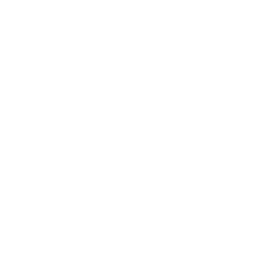
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Monitorowanie procesu walcowania w hucie stali</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Wielowymiarowa SPC do kontroli grubości i jakości powierzchni w walcowni taśm na gorąco &nbsp;|&nbsp; Marzec 2026</p>
</div>
</div>
</div>

## Streszczenie

Walcownia taśm na gorąco walcuje kęsiska stalowe na cienkie zwoje. Osiem
skorelowanych sygnałów procesowych (grubości, siła walcowania, szczelina
walców, prąd silnika, temperatura wyjściowa) zmienia się wspólnie, gdy
linia pracuje prawidłowo, więc monitorowanie ich pojedynczo, wykres po
wykresie, pomija wspólne przesunięcia, które mają znaczenie. Ten
przykład buduje wielowymiarowy model bazowy za pomocą **PROC MVPMODEL**,
a następnie przepuszcza przez **PROC MVPMONITOR** strumień 100 zwojów
produkcyjnych, który ocenia każdy zwój pojedynczą statystyką Hotellinga
*T*&sup2; i porównuje ją z granicą kontrolną.

Wobec granicy kontrolnej *T*&sup2; = **17,13** (&alpha; = 0,05),
**4 ze 100 zwojów** sygnalizują przekroczenie kontroli — zwoje **91, 92,
94 i 95**, dokładnie w oknie, w którym wprowadzono wybuch drgań walca
oporowego. Szczytowa wartość *T*&sup2; osiąga **21,91** przy zwoju 95,
czyli około **1,3&times;** granicy. Stopniowy wzrost zużycia walców w
późniejszych zwojach podnosi bazową wartość *T*&sup2;, ale pozostaje
poniżej granicy aż do zdarzenia drgań, więc wykres wyraźnie oddziela
powolny dryf od ostrego uszkodzenia wymagającego natychmiastowej uwagi.

## Źródła danych

- **mill_baseline** &mdash; 50 zwojów walcowanych w znanym dobrym okresie
  kampanii; używane do dopasowania wielowymiarowego modelu referencyjnego (PCA).
- **mill_stream** &mdash; 100 zwojów z linii produkcyjnej na żywo. Zwoje
  1&ndash;55 pracują w normie; zużycie walców narasta stopniowo w zwojach
  56&ndash;100; wybuch drgań walca oporowego uderza w zwoje 91&ndash;95.
- **Zmienne procesowe** (6): `entry_thickness`, `exit_thickness`,
  `rolling_force`, `roll_gap`, `motor_current`, `exit_temp`.

> Środowisko działa bez licencji, więc zbiory danych są ograniczone do 100
> obserwacji. Scenariusz jest dopasowany do tego limitu: zakłócenie
> umieszczono późno w strumieniu 100 zwojów, a nie przy zwoju 2800 z 5000.

---

### Krok 1 &mdash; Budowa wielowymiarowego modelu referencyjnego

`PROC MVPMODEL` wykonuje analizę głównych składowych sześciu zmiennych
procesowych na bazowym zbiorze w normie i zapisuje ładunki, wartości
własne oraz centrowanie/skalowanie do `mill_model`. Zachowane są trzy
składowe. Ten model definiuje, jak wygląda "normalność" jako pojedynczy
wielowymiarowy obszar, a nie sześć niezależnych zakresów.

In [1]:
DANE mill_baseline;
  CALL streaminit(66);
  POWTÓRZ coil_id = 1 TO 50;
    entry_thickness = 25.00 + rand('normal', 0, 0.30);
    exit_thickness  =  3.00 + rand('normal', 0, 0.030);
    rolling_force   = 18000 + rand('normal', 0, 150);
    roll_gap        =  2.85 + rand('normal', 0, 0.015);
    motor_current   =   850 + rand('normal', 0, 8);
    exit_temp       =   880 + rand('normal', 0, 4.0);
    WYJŚCIE;
  KONIEC;
WYKONAJ;

PROCEDURA mvpmodel DANE=mill_baseline outmodel=mill_model;
  ZMIENNA entry_thickness exit_thickness rolling_force
      roll_gap motor_current exit_temp;
  ncomp=3;
WYKONAJ;


                    The MVPMODEL Procedure

  Data Set:          mill_baseline
  Number of Variables: 6
  Missing Value Handling: Exclude
  Number of Observations Read: 50
  Number of Observations Used: 50
  Number of Principal Components: 3

  Correlation Matrix
         entry_thicknessexit_thicknessrolling_force  roll_gapmotor_current exit_temp
  entry_thickness    1.0000   -0.0416   -0.1641   -0.1661    0.1555    0.0649
  exit_thickness   -0.0416    1.0000    0.0406    0.0029    0.0946   -0.1421
  rolling_force   -0.1641    0.0406    1.0000   -0.1351    0.2077   -0.0051
  roll_gap   -0.1661    0.0029   -0.1351    1.0000   -0.0510   -0.0876
  motor_current    0.1555    0.0946    0.2077   -0.0510    1.0000    0.1587
  exit_temp    0.0649   -0.1421   -0.0051   -0.0876    0.1587    1.0000

  Eigenvalues of the Correlation Matrix
       Eigenvalue   Difference   Proportion  Cumulative
    1 1.37232115  0.14267284    0.2287    0.2287
    2 1.22964831  0.16747324    0.2049    0.4337
    3


NOTE: DATA mill_baseline


NOTE: Wrote mill_baseline (50 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MVPMODEL
NOTE: PROC MVPMODEL statement used.


---

### Krok 2 &mdash; Przepuszczenie zwojów produkcyjnych przez strumień i ich ocena

`PROC MVPMONITOR` rzutuje każdy ze 100 zwojów produkcyjnych na zapisany
model i oblicza jego statystykę Hotellinga *T*&sup2;. Procedura wyznacza
granicę kontrolną na podstawie wymiarów modelu oraz domyślnego
&alpha; = 0,05, a następnie oznacza każdy zwój, którego *T*&sup2; ją
przekracza. Wyniki, w tym kolumny `_TSQUARED`, `_LIMIT` i `_SIGNAL`, są
zapisywane do `mill_scores` z kluczem `coil_id`.

In [2]:
DANE mill_stream;
  CALL streaminit(42);
  POWTÓRZ coil_id = 1 TO 100;
    /* narastanie zużycia walców 0 -> 1 w zwojach 56-100 */
    wear    = MAX(0, coil_id - 55) / 45;
    /* wybuch drgań walca oporowego w zwojach 91-95 */
    chatter = (coil_id >= 91 AND coil_id <= 95);
    entry_thickness = 25.00 + rand('normal', 0, 0.30);
    exit_thickness  =  3.00 + wear*0.10 + chatter*0.35
                            + rand('normal', 0, 0.030);
    rolling_force   = 18000 + wear*600  + chatter*1600
                            + rand('normal', 0, 150);
    roll_gap        =  2.85 + wear*0.055
                            + rand('normal', 0, 0.015);
    motor_current   =   850 + wear*38   + chatter*95
                            + rand('normal', 0, 8);
    exit_temp       =   880 + rand('normal', 0, 4.0);
    USUŃ wear chatter;
    WYJŚCIE;
  KONIEC;
WYKONAJ;

PROCEDURA mvpmonitor DANE=mill_stream MODEL=mill_model
                out=mill_scores;
  ZMIENNA entry_thickness exit_thickness rolling_force
      roll_gap motor_current exit_temp;
  id coil_id;
WYKONAJ;


                    The MVPMONITOR Procedure

  Variables:       6
  Observations:    100
  T2 Limit:        17.1334
  Signals:         4





NOTE: DATA mill_stream


NOTE: Wrote mill_stream (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MVPMONITOR
NOTE: PROC MVPMONITOR statement used.


Podsumowanie procedury raportuje granicę kontrolną i liczbę sygnałów.
Poniżej wydrukowany fragment wokół zakłócenia pokazuje, że zwoje bazowe
pozostają wyraźnie poniżej granicy, podczas gdy okno drgań podnosi
cztery zwoje ponad nią.

In [3]:
/* Oznacz zwoje poza kontrolą i przechwyć alarmowe T2 do wykresu */
DANE mill_scores;
  USTAW mill_scores;
  JEŚLI _SIGNAL = 1 WTEDY t2_alarm = _TSQUARED;
  PRZECIWNIE t2_alarm = .;
WYKONAJ;

PROCEDURA print DANE=mill_scores(firstobs=88 obs=96) noobs;
  ZMIENNA coil_id _TSQUARED _LIMIT _SIGNAL;
  ETYKIETA coil_id='Nr zwoju' _TSQUARED='T2' _LIMIT='Granica kontrolna'
        _SIGNAL='Sygnał';
  TYTUŁ 'Wyniki T2 w oknie zakłócenia (zwoje 88-96)';
WYKONAJ;

                                       Wyniki T2 w oknie zakłócenia (zwoje 88-96)                                       

Nr zwoju         T2  Granica kontrolna   Sygnał
      88   9.983151          17.133408        0
      89   2.915646          17.133408        0
      90    7.80613          17.133408        0
      91  18.813814          17.133408        1
      92  18.249361          17.133408        1
      93  16.638221          17.133408        0
      94  17.981792          17.133408        1
      95  21.912329          17.133408        1
      96   5.118574          17.133408        0

... 4 more observations (showing 9 of 13)




NOTE: DATA mill_scores


NOTE: Read 100 rows from mill_scores.
NOTE: Wrote mill_scores (100 rows, 25 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds
NOTE: PROC PRINT data=mill_scores

NOTE: PROC PRINT completed: 9 observations printed, 4 variables


---

### Krok 3 &mdash; Wielowymiarowy wykres kontrolny

Wykres nakłada wartość *T*&sup2; dla każdego zwoju na jego granicę
kontrolną. Zwoje poza kontrolą są wyróżnione na czerwono; przerywany
znacznik pionowy oznacza początek wybuchu drgań. Powolny wzrost w
prawej części wykresu to narastające zużycie walców podnoszące poziom
bazowy; cztery czerwone punkty to ostre uszkodzenie związane z drganiami.

                                       Wyniki T2 w oknie zakłócenia (zwoje 88-96)                                       




NOTE: PROC SGPLOT data=mill_scores

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


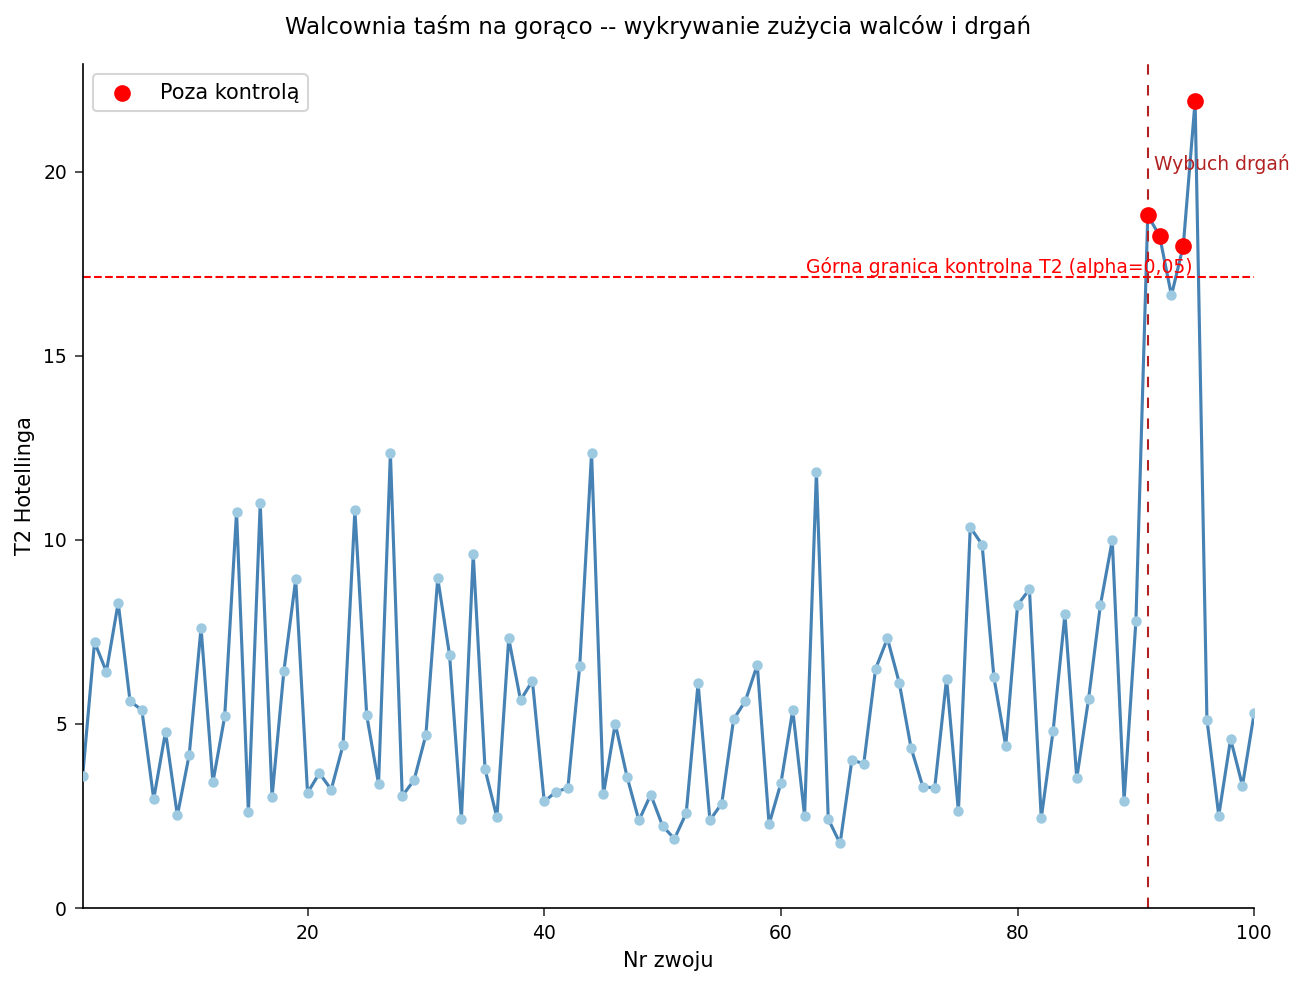

In [4]:
PROCEDURA SGPLOT DANE=mill_scores;
  SERIES  x=coil_id y=_TSQUARED /
          LINEATTRS=(color=steelblue thickness=1.5);
  SCATTER x=coil_id y=_TSQUARED /
          MARKERATTRS=(SYMBOL=circlefilled size=4 color=cx9ecae1);
  SCATTER x=coil_id y=t2_alarm /
          MARKERATTRS=(SYMBOL=circlefilled size=7 color=red)
          legendlabel='Poza kontrolą';
  REFLINE _LIMIT / AXIS=y
          ETYKIETA='Górna granica kontrolna T2 (alpha=0,05)'
          LINEATTRS=(color=red pattern=dash);
  REFLINE 91 / AXIS=x ETYKIETA='Wybuch drgań'
          LINEATTRS=(color=firebrick pattern=shortdash);
  XAXIS ETYKIETA='Nr zwoju' MIN=1 MAX=100;
  YAXIS ETYKIETA="T2 Hotellinga" MIN=0;
  TYTUŁ 'Walcownia taśm na gorąco -- wykrywanie zużycia walców i drgań';
WYKONAJ;

---

### Krok 4 &mdash; Ilościowe ujęcie zwojów poza kontrolą

Zwoje poza kontrolą są kierowane do osobnego zbioru danych dla działu
jakości. `PROC MEANS` zestawia poziom *T*&sup2; oznaczonych zwojów z
populacją w normie, a oznaczone zwoje są eksportowane do dalszego
routingu brakowania/naprawy.

In [5]:
DANE mill_ooc;
  USTAW mill_scores;
  JEŚLI _SIGNAL = 1;
WYKONAJ;

PROCEDURA means DANE=mill_scores n mean MAX maxdec=2;
  KLASA _SIGNAL;
  ZMIENNA _TSQUARED;
  ETYKIETA _SIGNAL='Sygnał' _TSQUARED='T2';
  TYTUŁ 'T2 według stanu kontroli (0 = w normie, 1 = sygnał)';
WYKONAJ;

PROCEDURA print DANE=mill_ooc noobs;
  ZMIENNA coil_id _TSQUARED _LIMIT;
  ETYKIETA coil_id='Nr zwoju' _TSQUARED='T2' _LIMIT='Granica kontrolna';
  TYTUŁ 'Zwoje poza kontrolą oznaczone do inspekcji';
WYKONAJ;

PROCEDURA export DANE=mill_ooc
            OUTFILE='steel_mill_ooc_coils.csv'
            DBMS=csv REPLACE;
WYKONAJ;

                                  T2 według stanu kontroli (0 = w normie, 1 = sygnał)                                   

                                                  The MEANS Procedure

                                            Analysis Variable : _TSQUARED T2

        Sygnał            N Obs           Mean        Maximum
        -----------------------------------------------------
        0                    96           5.39          16.64
        1                     4          19.24          21.91
        -----------------------------------------------------

                                       Zwoje poza kontrolą oznaczone do inspekcji                                       

Nr zwoju         T2  Granica kontrolna
      91  18.813814          17.133408
      92  18.249361          17.133408
      94  17.981792          17.133408
      95  21.912329          17.133408




NOTE: DATA mill_ooc


NOTE: Read 100 rows from mill_scores.
NOTE: Wrote mill_ooc (4 rows, 25 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=mill_ooc

NOTE: PROC PRINT completed: 4 observations printed, 3 variables
NOTE: PROC EXPORT data=mill_ooc outfile=steel_mill_ooc_coils.csv

NOTE: Exported 4 rows to steel_mill_ooc_coils.csv.


## Wnioski

- **Monitorowane zwoje**: 100; **granica kontrolna** *T*&sup2; = **17,13**
  (&alpha; = 0,05).
- **Zwoje poza kontrolą**: **4** &mdash; zwoje **91, 92, 94, 95**, wszystkie
  wewnątrz wprowadzonego okna drgań (91&ndash;95). Zwój 93 osiąga szczyt
  przy *T*&sup2; = 16,64, tuż poniżej granicy.
- **Szczytowa dotkliwość**: *T*&sup2; = **21,91** przy zwoju 95 (około
  1,3&times; granicy); zwoje w normie mają średnio *T*&sup2; &asymp; **5,4**.
- **Zużycie a uszkodzenie**: stopniowe narastanie zużycia walców podnosi
  poziom bazowy w późniejszych zwojach, ale nigdy samo z siebie nie
  przekracza granicy, więc pojedynczy wykres wielowymiarowy odróżnia
  powolny dryf (do obserwacji) od ostrego zdarzenia drgań (do
  natychmiastowego działania).
- **Działanie**: cztery oznaczone zwoje są eksportowane do
  `steel_mill_ooc_coils.csv` do inspekcji i routingu brakowania/naprawy;
  sygnatura drgań wskazuje na łożysko walca oporowego jako element do
  sprawdzenia przed następną kampanią.

---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>